<div align="center" style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding:35px;
    border-radius:15px;
    box-shadow:0 8px 25px rgba(0,0,0,0.25);
">
  <h1 style="
      color:white;
      font-family: 'Segoe UI', sans-serif;
      margin:0;
      font-size:42px;
      letter-spacing:1px;
  ">
     Customer Churn Predication by Prince Kumar
  </h1>
</div>

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.regularizers import l2

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

In [4]:
df.shape

(10000, 14)

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
df.duplicated().sum()

np.int64(0)

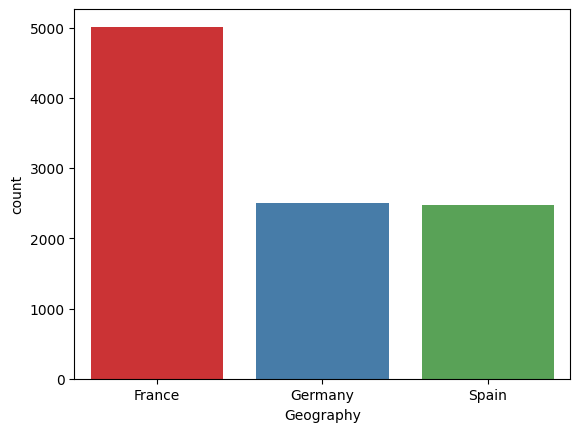

In [9]:
sns.barplot(df['Geography'].value_counts(),palette='Set1');

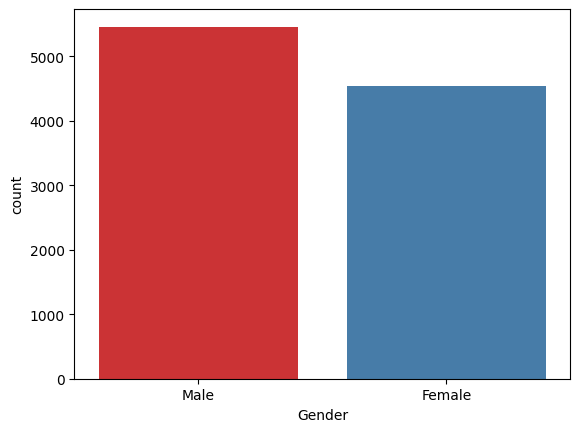

In [10]:
sns.barplot(df['Gender'].value_counts(),palette='Set1');

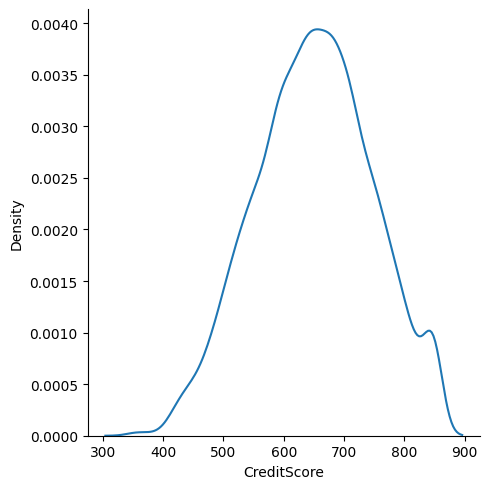

In [11]:
sns.displot(df['CreditScore'],kind='kde')

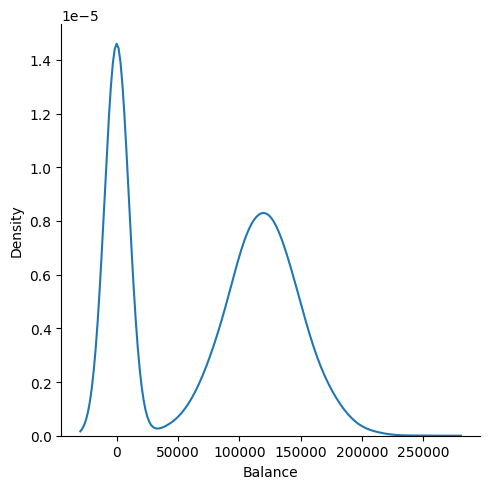

In [12]:
sns.displot(df['Balance'],kind='kde')

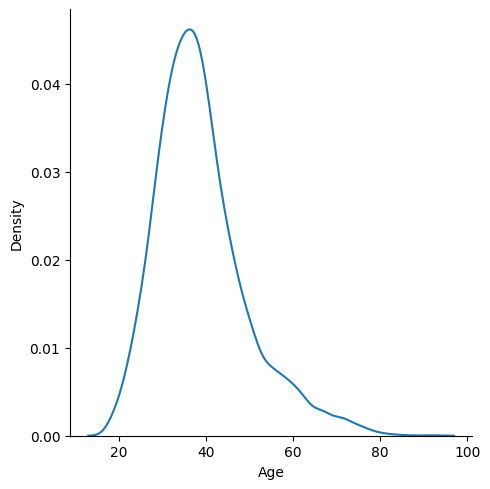

In [13]:
sns.displot(df['Age'],kind='kde')

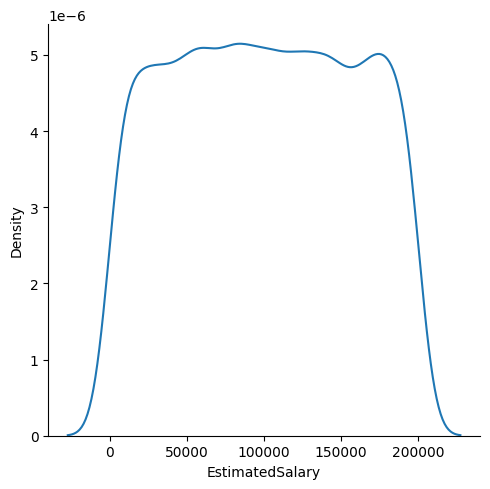

In [14]:
sns.displot(df['EstimatedSalary'],kind='kde')

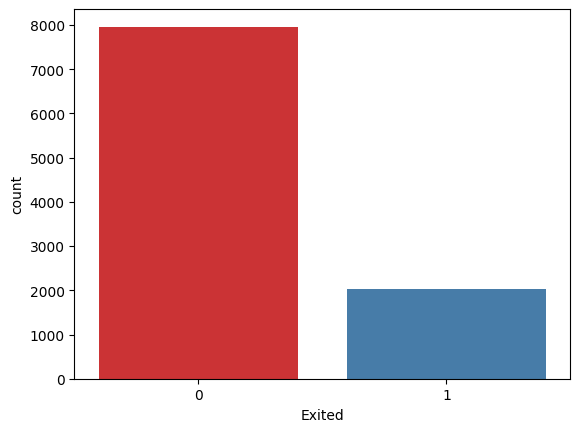

In [15]:
sns.barplot(df['Exited'].value_counts(),palette='Set1');

In [16]:
df['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

<Axes: xlabel='Tenure', ylabel='count'>

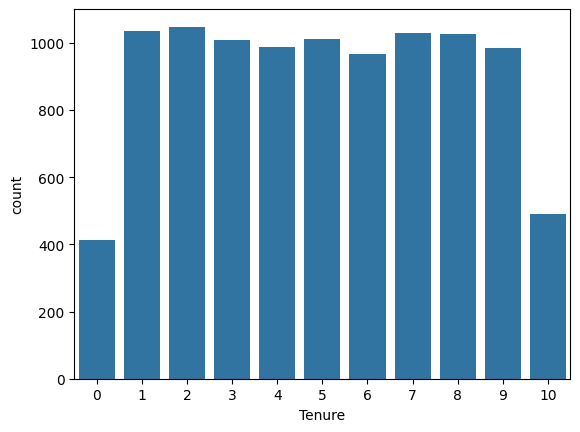

In [17]:
sns.barplot(df['Tenure'].value_counts())

In [18]:
X = df.iloc[:,3:-1]

In [19]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [20]:
y = df.iloc[:,-1]

In [21]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [22]:
X = pd.get_dummies(X,columns=['Geography','Gender'],drop_first=True)

In [23]:
X.shape

(10000, 11)

In [24]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [25]:
ss = StandardScaler()

In [26]:
x_scaled = ss.fit_transform(X)

In [27]:
x_train , x_test , y_train , y_test = train_test_split(x_scaled, y,test_size=0.1,random_state=42)

In [28]:
x_train.shape

(9000, 11)

In [29]:
y_train.shape

(9000,)

In [67]:
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=11, kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

In [68]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [82]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=100,
    callbacks=[early_stop]
)

Epoch 1/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8672 - loss: 0.3431 - val_accuracy: 0.8522 - val_loss: 0.3573
Epoch 2/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8665 - loss: 0.3434 - val_accuracy: 0.8556 - val_loss: 0.3562
Epoch 3/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8677 - loss: 0.3466 - val_accuracy: 0.8544 - val_loss: 0.3561
Epoch 4/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8669 - loss: 0.3403 - val_accuracy: 0.8544 - val_loss: 0.3583
Epoch 5/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8664 - loss: 0.3422 - val_accuracy: 0.8567 - val_loss: 0.3562
Epoch 6/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8678 - loss: 0.3433 - val_accuracy: 0.8567 - val_loss: 0.3574
Epoch 7/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8657 - loss: 0.3420 - val_accuracy: 0.8544 - val_loss: 0.3582
Epoch 8/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8665 - loss: 0.3420 - val_accu

In [83]:
model.layers[0].get_weights()

[array([[-6.74738958e-02,  2.18751578e-04,  2.28947625e-02,
         -1.41470134e-02, -8.47503021e-02, -1.45712852e-01,
          4.15177010e-02,  6.34640157e-02, -1.19211746e-03,
          1.80633720e-02,  5.67962117e-02,  3.84736732e-02,
         -5.10034226e-02, -5.74041717e-02,  5.98491961e-03,
          2.32656909e-33,  2.08959579e-02, -9.83962417e-03,
          1.22297807e-02, -3.57443914e-02,  1.18269678e-02,
          1.58366887e-03,  3.99777927e-02, -1.37167377e-02,
          2.01814976e-02,  7.47512560e-03, -3.37215625e-02,
          5.96654899e-02, -2.08951626e-02,  5.22244759e-02,
          2.22654641e-01, -8.83934833e-03, -7.48222545e-02,
          1.92751549e-02,  5.02694305e-03,  6.91602528e-02,
          1.05358902e-02, -1.27220508e-02, -5.80055267e-02,
         -1.06762443e-03,  5.79019077e-02,  3.76369655e-02,
         -2.58148145e-02,  7.32686324e-03,  1.74135976e-02,
         -2.18622107e-03, -3.94535222e-04, -4.00452316e-02,
         -5.60746379e-02, -2.21753512e-0

In [88]:
y_pred = model.predict(x_test)
y_pred

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


array([[0.04260329],
       [0.02253243],
       [0.07634588],
       [0.14501916],
       [0.06990061],
       [0.00932135],
       [0.15038602],
       [0.2098369 ],
       [0.18762101],
       [0.31981185],
       [0.9071924 ],
       [0.93474877],
       [0.7426921 ],
       [0.32674286],
       [0.02342726],
       [0.20698938],
       [0.08038687],
       [0.08089493],
       [0.02653232],
       [0.0548357 ],
       [0.07695404],
       [0.00755889],
       [0.10354138],
       [0.23587988],
       [0.04925555],
       [0.38840342],
       [0.09074324],
       [0.05108846],
       [0.01725402],
       [0.12172378],
       [0.08556576],
       [0.03706583],
       [0.1736136 ],
       [0.03372049],
       [0.15081537],
       [0.81260663],
       [0.32822034],
       [0.02285586],
       [0.1418706 ],
       [0.02249818],
       [0.12976925],
       [0.5606291 ],
       [0.01535847],
       [0.06083579],
       [0.13356233],
       [0.03922668],
       [0.03115916],
       [0.077

In [89]:
np.where(y_pred>0.5,1,0)

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
    

In [90]:
y_pred = y_pred.argmax(axis=-1)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [91]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.809

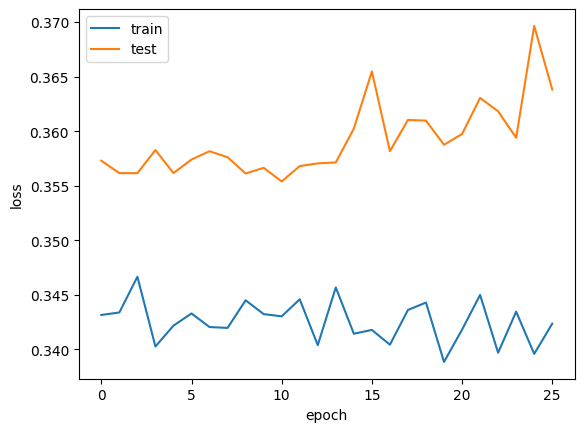

In [94]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

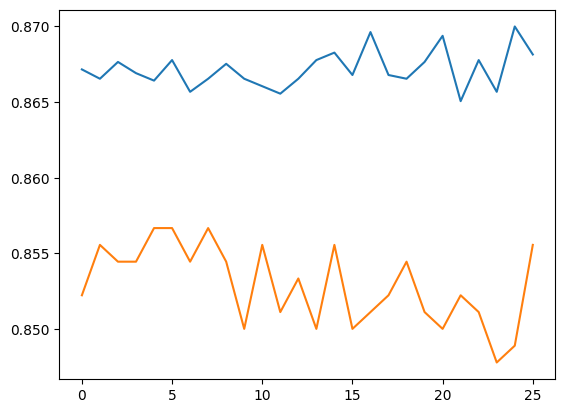

In [95]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])